In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm import tqdm
import albumentations as augmentation
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
root_dir = "/kaggle/input/multichannel-glaucoma-benchmark-dataset"
metadata = pd.read_csv(os.path.join(root_dir, "metadata - standardized.csv"))
metadata = metadata[
    ~metadata['fundus_oc_seg'].isnull() &
    (metadata['fundus_oc_seg'] != 'Not Visible') &
    ~metadata['fundus_od_seg'].isnull()
].reset_index(drop=True)

In [3]:
def apply_clahe_and_median(image_np):
    """
    Applying CLAHE + median filter on RGB image (numpy array).
    """
    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged_lab = cv2.merge((cl, a, b))
    enhanced_rgb = cv2.cvtColor(merged_lab, cv2.COLOR_LAB2RGB)

    # Median filter for reducing noise while preserving edges
    denoised_rgb = cv2.medianBlur(enhanced_rgb, ksize=3)

    return denoised_rgb

In [4]:
class FundusSegmentationDataset(Dataset):
    def __init__(self, metadata, root_dir, image_size=128, augment=False):
        self.metadata = metadata
        self.root_dir = root_dir
        self.image_size = image_size
        self.augment = augment

        self.aug_transform = augmentation.Compose([
            augmentation.Resize(image_size, image_size),
            augmentation.HorizontalFlip(p=0.5),
            augmentation.RandomBrightnessContrast(p=0.2),
            augmentation.Affine(scale=(0.95, 1.05), translate_percent=(0.02, 0.02), rotate=(-15, 15), p=0.5),
            augmentation.GaussianBlur(p=0.1),
            augmentation.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # normalize to mean=0, std=1
            ToTensorV2(),
        ])

        self.simple_transform = augmentation.Compose([
            augmentation.Resize(image_size, image_size),
            augmentation.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # normalize to mean=0, std=1
            # transforms.ToTensor()
            ToTensorV2(),
        ])

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        fundus_path = os.path.join(self.root_dir, "full-fundus" + row['fundus'])
        od_path = os.path.join(self.root_dir, "optic-disc" + row['fundus_od_seg'])
        oc_path = os.path.join(self.root_dir, "optic-cup" + row['fundus_oc_seg'])
    
        # === Apply CLAHE + Median ===
        raw_image = np.array(Image.open(fundus_path).convert("RGB"))
        fundus = apply_clahe_and_median(raw_image)
    
        od = np.array(Image.open(od_path))
        oc = np.array(Image.open(oc_path))
    
        mask = np.zeros_like(od)
        mask[od != 0] = 2  # OD = 2
        mask[oc != 0] = 1  # OC = 1
    
        if self.augment:
            transformed = self.aug_transform(image=fundus, mask=mask)
            # fundus = transformed['image']
            # mask = transformed['mask'].long()
        else:
            transformed = self.simple_transform(image=fundus, mask=mask)
            # mask = Image.fromarray(mask).resize((self.image_size, self.image_size), Image.NEAREST)
            # mask = torch.from_numpy(np.array(mask)).long()
        
        fundus = transformed['image']
        mask = transformed['mask'].long()
    
        return fundus, mask

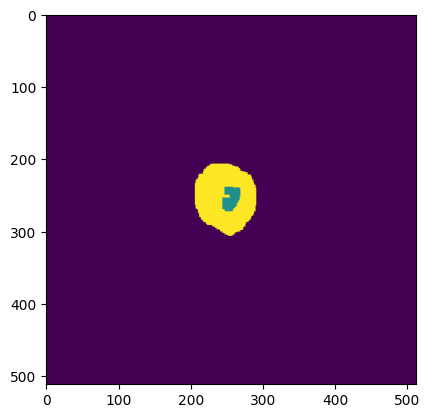

In [4]:
od_test = np.array(Image.open("/kaggle/input/multichannel-glaucoma-benchmark-dataset/optic-disc/optic-disc/CRFO-v4-1.png"))
oc_test = np.array(Image.open("/kaggle/input/multichannel-glaucoma-benchmark-dataset/optic-cup/optic-cup/CRFO-v4-1.png"))

mask_test = np.zeros_like(od_test)
mask_test[od_test != 0] = 2  # OD = 2
mask_test[oc_test != 0] = 1  # OC = 1

plt.imshow(mask_test)

In [5]:
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())

        
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        combined = F.relu(g1 + x1)
        attention_mask = self.psi(combined)

        return x * attention_mask

In [6]:
class ConvBlock(nn.Module):
    """Double convolution block"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

In [7]:
class UpConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.up(x)

In [8]:
class AttentionUNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # === using the resnet50 model ===
        resnet = models.resnet50(weights='DEFAULT')
        
        # Encoder
        self.enc0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # 64 channels
        self.enc1 = resnet.maxpool  # Still 64 channels
        self.enc2 = resnet.layer1  # 256 channels
        self.enc3 = resnet.layer2  # 512 channels
        self.enc4 = resnet.layer3  # 1024 channels
        self.center = resnet.layer4  # 2048 channels
        
        # Decoder with proper channel dimensions
        self.up4 = UpConv(2048, 1024)
        self.att4 = AttentionBlock(F_g=1024, F_l=1024, F_int=512)
        self.dec4 = ConvBlock(2048, 1024)  # Concatenated: 1024 + 1024
        
        self.up3 = UpConv(1024, 512)
        self.att3 = AttentionBlock(F_g=512, F_l=512, F_int=256)
        self.dec3 = ConvBlock(1024, 512)  # Concatenated: 512 + 512
        
        self.up2 = UpConv(512, 256)
        self.att2 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.dec2 = ConvBlock(512, 256)  # Concatenated: 256 + 256
        
        self.up1 = UpConv(256, 64)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec1 = ConvBlock(128, 64)  # Concatenated: 64 + 64
        
        self.final = nn.Conv2d(64, num_classes, 1)
    
    def forward(self, x):
        # Encoder
        e0 = self.enc0(x)      # 64
        e1 = self.enc1(e0)     # 64
        e2 = self.enc2(e1)     # 256
        e3 = self.enc3(e2)     # 512
        e4 = self.enc4(e3)     # 1024
        c = self.center(e4)    # 2048
        
        # Decoder with attention
        d4 = self.up4(c)                           # 1024
        e4_att = self.att4(g=d4, x=e4)            # 1024
        d4 = torch.cat([d4, e4_att], dim=1)       # 2048
        d4 = self.dec4(d4)                         # 1024
        
        d3 = self.up3(d4)                          # 512
        e3_att = self.att3(g=d3, x=e3)            # 512
        d3 = torch.cat([d3, e3_att], dim=1)       # 1024
        d3 = self.dec3(d3)                         # 512
        
        d2 = self.up2(d3)                          # 256
        e2_att = self.att2(g=d2, x=e2)            # 256
        d2 = torch.cat([d2, e2_att], dim=1)       # 512
        d2 = self.dec2(d2)                         # 256
        
        d1 = self.up1(d2)                          # 64
        e0_att = self.att1(g=d1, x=e0)            # 64
        d1 = torch.cat([d1, e0_att], dim=1)       # 128
        d1 = self.dec1(d1)                         # 64
        
        out = self.final(d1)
        return out

In [9]:
class StandardUNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # === using the resnet50 model ===
        resnet = models.resnet50(weights='DEFAULT')
        
        self.enc1 = nn.Sequential(*list(resnet.children())[:3])
        self.enc2 = nn.Sequential(*list(resnet.children())[3:5])
        self.enc3 = resnet.layer2
        self.enc4 = resnet.layer3
        self.center = resnet.layer4
    
        # Decoder 
        # Note: in_ch is now (Upsampled features + Skip features)
        # Because we are CONCATENATING them!
        self.up4 = UpConv(2048, 1024) 
        self.conv4 = nn.Conv2d(1024 + 1024, 1024, 3, padding=1) # 1024 (up) + 1024 (skip)
        
        self.up3 = UpConv(1024, 512)
        self.conv3 = nn.Conv2d(512 + 512, 512, 3, padding=1)
        
        self.up2 = UpConv(512, 256)
        self.conv2 = nn.Conv2d(256 + 256, 256, 3, padding=1)
        
        self.up1 = UpConv(256, 64)
        self.conv1 = nn.Conv2d(64 + 64, 64, 3, padding=1)
    
        self.final = nn.Conv2d(64, num_classes, 1)
    
    def forward(self, x):
        # Encoder
        e1 = self.enc1(x); e2 = self.enc2(e1); e3 = self.enc3(e2)
        e4 = self.enc4(e3); c = self.center(e4)
        
        # Decoder with Concatenation
        # 1. Upsample the lower layer
        # 2. Concatenate with the skip connection
        # 3. Apply a convolution to merge them
        
        d4 = self.up4(c)
        d4 = torch.cat([d4, e4], dim=1) # Concatenate along channels
        d4 = self.conv4(d4)
        
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.conv3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.conv2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.conv1(d1)
        
        return self.final(d1)

In [ ]:
# === DICE FUNCTION ===
def dice_score(pred, target, class_idx):
    pred = (pred == class_idx).float()
    target = (target == class_idx).float()
    
    numerator = 2 * (pred * target).sum()
    denominator = pred.sum() + target.sum() + 1e-6 # <=== 1e-6 to prevent divide by zero error
    return numerator / denominator

In [ ]:
# === TRAINING LOOP ===
def train_with_earlystop(model, train_loader, val_loader, epochs=500, patience=50): 
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'val_loss': [], 'dice_oc': [], 'dice_od': []}
    best_val_loss = float('inf')
    patience_counter = 0

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for img, mask in train_loader:
            img, mask = img.to(device), mask.to(device)
            pred = model(img)
            pred = F.interpolate(pred,
                                 size=mask.shape[-2:],
                                 mode='bilinear',
                                 align_corners=False) # <=== this resizes the pred to match dimension of mask ===
            loss = criterion(pred, mask)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        dices = {'oc': [], 'od': []}
        with torch.no_grad():
            for img, mask in val_loader:
                img, mask = img.to(device), mask.to(device)
                pred = model(img)
                pred = F.interpolate(pred,
                                     size=mask.shape[-2:],
                                     mode='bilinear',
                                     align_corners=False)
                loss = criterion(pred, mask)
                val_loss += loss.item()
                pred_label = torch.argmax(pred, dim=1)
                dices['oc'].append(dice_score(pred_label, mask, 1).item())
                dices['od'].append(dice_score(pred_label, mask, 2).item())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        mean_oc = np.mean(dices['oc'])
        mean_od = np.mean(dices['od'])

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['dice_oc'].append(mean_oc)
        history['dice_od'].append(mean_od)

        print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Dice OC: {mean_oc:.4f} | Dice OD: {mean_od:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "attention_unet_best.pt")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"⏳ Early stopping patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("🛑 Early stopping triggered.")
                break

    return history

In [ ]:
def validate_image_paths(df, root_dir):
    valid_rows = []
    for i, row in df.iterrows():
        fundus_path = os.path.join(root_dir, "full-fundus" + row['fundus'])
        od_path = os.path.join(root_dir, "optic-disc" + row['fundus_od_seg'])
        oc_path = os.path.join(root_dir, "optic-cup" + row['fundus_oc_seg'])
        if all(os.path.exists(p) for p in [fundus_path, od_path, oc_path]):
            valid_rows.append(i)
    return df.iloc[valid_rows].reset_index(drop=True)

metadata_filtered = validate_image_paths(metadata, root_dir)
print(f"✅ Total valid samples: {len(metadata_filtered)}")

In [ ]:
# Manual split index to control augmentation only in training
indices = np.arange(len(metadata))
np.random.seed(42)
np.random.shuffle(indices)
train_idx = indices[:-200]
val_idx = indices[-200:-100]
test_idx = indices[-100:]

In [ ]:
# Dataset with augmentation is for training only
train_set = FundusSegmentationDataset(metadata.iloc[train_idx], root_dir, augment=True)
val_set   = FundusSegmentationDataset(metadata.iloc[val_idx], root_dir, augment=False)
test_set  = FundusSegmentationDataset(metadata.iloc[test_idx], root_dir, augment=False)

In [ ]:
# DataLoaders
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=8)
test_loader  = DataLoader(test_set, batch_size=8)

In [ ]:
# Model Initialization
model = AttentionUNet(num_classes=3)
history = train_with_earlystop(model, train_loader, val_loader, epochs=500)

In [ ]:
# Plot Metric
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()
plt.subplot(1,2,2); plt.plot(history['dice_oc'], label='Dice OC')
plt.plot(history['dice_od'], label='Dice OD')
plt.title("Dice Score")
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
def evaluate_and_visualize(model, test_loader, num_samples=4):
    """
    Mengevaluasi model pada data test dan menampilkan hasil Dice Score serta visualisasi prediksi vs ground truth.
    """
    model.eval()
    model.to(device)

    dice_oc_scores = []
    dice_od_scores = []
    samples = []

    with torch.no_grad():
        for i, (img, mask) in enumerate(test_loader):
            img, mask = img.to(device), mask.to(device)
            pred = model(img)
            pred = F.interpolate(pred, size=mask.shape[-2:], mode='bilinear', align_corners=False)
            pred_label = torch.argmax(pred, dim=1)

            dice_oc_scores.append(dice_score(pred_label, mask, 1).item())
            dice_od_scores.append(dice_score(pred_label, mask, 2).item())

            if len(samples) < num_samples:
                for j in range(min(len(img), num_samples - len(samples))):
                    samples.append((img[j].cpu(), mask[j].cpu(), pred_label[j].cpu()))

    print(f"🧪 Test Dice Score - Optic Cup (OC): {np.mean(dice_oc_scores):.4f}")
    print(f"🧪 Test Dice Score - Optic Disc (OD): {np.mean(dice_od_scores):.4f}")


    def denormalize(tensor):
        """Denormalize image tensor from ImageNet normalization"""
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = tensor * std + mean
        img = torch.clamp(img, 0, 1)  # Ensure values are in [0, 1]
        return img.permute(1, 2, 0).numpy()
    
    def decode_mask(mask_tensor):
        mask = mask_tensor.numpy()
        vis = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
        vis[mask == 1] = [255, 0, 0]   # OC = merah
        vis[mask == 2] = [0, 255, 0]   # OD = hijau
        return vis

    fig, axs = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    for i, (img, true_mask, pred_mask) in enumerate(samples):
        # axs[i, 0].imshow(img.permute(1, 2, 0))
        axs[i, 0].imshow(denormalize(img))
        axs[i, 0].set_title("Fundus Image")
        axs[i, 1].imshow(decode_mask(true_mask))
        axs[i, 1].set_title("Ground Truth Mask")
        axs[i, 2].imshow(decode_mask(pred_mask))
        axs[i, 2].set_title("Predicted Mask")
        for ax in axs[i]: ax.axis('off')

    plt.tight_layout()
    plt.show()


In [2]:
# === Evaluation ===
model = AttentionUNet(num_classes=3)
model.load_state_dict(torch.load("attention_unet_best.pt"))
evaluate_and_visualize(model, test_loader, num_samples=4)

NameError: name 'AttentionUNet' is not defined

In [17]:
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load your trained U-Net
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = '/kaggle/input/unet-glaucoma-v1/pytorch/default/1/attention_unet_best.pt'
# 1. Initialize the ACTUAL model object (nn.Module)
unet_model = AttentionUNet(num_classes=3)

# 2. Load the weights into a SEPARATE variable (OrderedDict)
weights = torch.load(model_path, map_location=device)

# 3. Load the weights INTO the model object
# Note: Check if your checkpoint is wrapped in another dictionary
if isinstance(weights, dict) and 'model_state_dict' in weights:
    unet_model.load_state_dict(weights['model_state_dict'])
else:
    unet_model.load_state_dict(weights)

# 4. Move to device and set to eval
unet_model.to(device)
unet_model.eval()

def get_mask(image_path):
    # Preprocess same as your training
    img = Image.open(image_path).convert('RGB')
    img_input = img.resize((256, 256)) 
    img_tensor = torch.from_numpy(np.array(img_input)).permute(2,0,1).float().unsqueeze(0) / 255.0
    
    with torch.no_grad():
        pred_mask = unet_model(img_tensor.to(device))
        # Assuming 2 channels (0: Disk, 1: Cup)
        pred_mask = torch.sigmoid(pred_mask).cpu().numpy()[0]
    
    return pred_mask # Returns [2, 256, 256]

In [18]:
import timm # Library for state-of-the-art vision models

class GlaucomaViT(torch.nn.Module):
    def __init__(self, model_name='vit_base_patch16_224', num_classes=2):
        super(GlaucomaViT, self).__init__()
        # We use a 4-channel input (RGB + Mask) to give the ViT structural guidance
        self.model = timm.create_model(model_name, pretrained=True, in_chans=4)
        self.model.head = torch.nn.Linear(self.model.head.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

vit_classifier = GlaucomaViT().to(device)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [20]:
def prepare_hybrid_input(image_path):
    # 1. Get original image
    raw_img = cv2.imread(image_path)
    raw_img = cv2.resize(raw_img, (224, 224)) / 255.0
    
    # 2. Get mask from U-Net
    mask = get_mask(image_path) # [2, 256, 256]
    # Resize mask to match ViT input and flatten to 1 channel for simplicity 
    # (or use 2 channels for 5-channel input)
    mask_resized = cv2.resize(mask[0], (224, 224)) 
    
    # 3. Concatenate: (224, 224, 3) + (224, 224, 1) = (224, 224, 4)
    hybrid_input = np.concatenate([raw_img, mask_resized[..., None]], axis=-1)
    return torch.from_numpy(hybrid_input).permute(2,0,1).float()

In [21]:
!pip install timm # Install state-of-the-art vision models
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import timm
from tqdm import tqdm
import os

# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
UNET_PATH = '/kaggle/input/unet-glaucoma-v1/pytorch/default/1/attention_unet_best.pt'
DATA_DIR = '/kaggle/input/multichannel-glaucoma-benchmark-dataset'
BATCH_SIZE = 16
IMG_SIZE = 224 # ViT standard size

In [22]:
class GlaucomaHybridDataset(Dataset):
    def __init__(self, csv_file, root_dir, unet_model, transform=None):
        self.data = pd.read_csv(os.path.join(root_dir, csv_file))
        self.root_dir = root_dir
        self.unet = unet_model
        self.transform = transform
        self.unet.eval()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 1. Load Image
        img_name = os.path.join(self.root_dir, self.data.iloc[idx]['fundus'])
        image = Image.open(img_name).convert('RGB')
        
        # 2. Generate Mask using your U-Net (Segmentation Stage)
        with torch.no_grad():
            # Prep for U-Net (assuming it takes 256x256)
            input_unet = transforms.Resize((256, 256))(image)
            input_unet = transforms.ToTensor()(input_unet).unsqueeze(0).to(DEVICE)
            mask = self.unet(input_unet)
            mask = torch.sigmoid(mask).squeeze(0).cpu() # [Channels, 256, 256]
            # Take the max or average of cup/disc channels for a single heatmap
            mask = torch.mean(mask, dim=0, keepdim=True) 

        # 3. Hybrid Input: Combine RGB and Mask
        image_np = np.array(image.resize((IMG_SIZE, IMG_SIZE)))
        mask_np = np.array(transforms.ToPILImage()(mask).resize((IMG_SIZE, IMG_SIZE)))
        
        # Stack to create a 4-channel image [H, W, 4]
        hybrid_img = np.dstack([image_np, mask_np])
        
        if self.transform:
            hybrid_img = self.transform(hybrid_img)
            
        label = int(self.data.iloc[idx]['types']) # 0: Healthy, 1: Glaucoma
        # Handle cases where label is -1 (suspect) - usually mapped to 1 or ignored
        label = 1 if label != 0 else 0 
        
        return hybrid_img, label

# Initialize your U-Net
unet_model = torch.load(UNET_PATH, map_location=DEVICE)

In [23]:
class GlaucomaViT(nn.Module):
    def __init__(self):
        super(GlaucomaViT, self).__init__()
        # 'vit_base_patch16_224' is the research standard
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, in_chans=4)
        
        # Replace the head for binary classification (Glaucoma vs. Normal)
        self.vit.head = nn.Sequential(
            nn.Linear(self.vit.head.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        return self.vit(x)

model = GlaucomaViT().to(DEVICE)

In [24]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss/len(loader), 100.*correct/total

# Example usage:
# train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
# criterion = nn.CrossEntropyLoss()

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

class EarlyStopping:
    def __init__(self, patience=7, delta=0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def calculate_metrics(y_true, y_pred, y_probs):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs)
    return precision, recall, f1, auc

In [32]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torchvision.transforms as T

# 1. Load the main dataframe
df = pd.read_csv('/kaggle/input/multichannel-glaucoma-benchmark-dataset/metadata - standardized.csv') 

# 2. Split into Train (80%) and Validation (20%)
# Use stratify to ensure both sets have an equal percentage of glaucoma cases
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['types'], random_state=42)

# Save these to temporary CSVs so the Dataset class can read them
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)

# 3. Define Image Augmentation (Crucial for ViT performance)
# We use standard 3-channel transforms; the 4th channel (mask) will be handled in the __getitem__
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406, 0.5], std=[0.229, 0.224, 0.225, 0.225]) 
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406, 0.5], std=[0.229, 0.224, 0.225, 0.225])
])

# 4. Create Dataset Objects
train_dataset = GlaucomaHybridDataset(
    csv_file='/kaggle/working/train_split.csv', 
    root_dir=DATA_DIR, 
    unet_model=unet_model, 
    transform=train_transform
)

val_dataset = GlaucomaHybridDataset(
    csv_file='/kaggle/working/val_split.csv', 
    root_dir=DATA_DIR, 
    unet_model=unet_model, 
    transform=val_transform
)

# 5. Create the Loaders (This solves your NameError!)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"DataLoaders Ready: {len(train_dataset)} train images, {len(val_dataset)} val images.")

AttributeError: 'collections.OrderedDict' object has no attribute 'eval'

In [26]:
import torch.optim as optim

# Hyperparameters for ViT
num_epochs = 30
learning_rate = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
early_stopper = EarlyStopping(patience=5)

history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate Metrics
    v_loss = val_loss / len(val_loader)
    precision, recall, f1, auc = calculate_metrics(all_labels, all_preds, all_probs)
    accuracy = (np.array(all_labels) == np.array(all_preds)).mean()

    print(f"Epoch {epoch+1}: Val Loss: {v_loss:.4f} | Acc: {accuracy:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

    # Save Best Model
    if v_loss < early_stopper.best_loss:
        torch.save(model.state_dict(), 'vit_glaucoma_best.pth')
        print("--> Best Model Saved")

    early_stopper(v_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered.")
        break

NameError: name 'train_loader' is not defined

In [27]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Glaucoma'], yticklabels=['Healthy', 'Glaucoma'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Glaucoma Detection: ViT-Hybrid Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.show()

# Use the lists from your best validation epoch
plot_confusion_matrix(all_labels, all_preds)

NameError: name 'all_labels' is not defined